### Análisis y preprocesamiento de los datos 

In [111]:
# importaciones
import pandas as pd
import matplotlib.pyplot as plt

In [112]:
features_df = pd.read_csv("../data/datasets/9694_ECG_features.csv")
metadata_df = pd.read_csv("../data/datasets/ecg_records_metadata.csv")

In [113]:
features_df.head()

,ECG_ID,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude
0,A00002,210.923077,106.153846,-0.014168,0.952739,-0.053873,0.063098
1,A00003,207.125000,106.750000,0.153767,0.422575,-0.099085,0.064254
2,A00006,208.200000,122.600000,0.051325,0.513801,-0.073265,0.132976
3,A00008,190.200000,109.600000,0.055782,0.712922,-0.091710,0.193799
4,A00009,160.666667,100.333333,0.068612,0.492980,-0.134314,0.145174


In [114]:
metadata_df.head()

,ECG_ID,Age,AHA_Code,Patient_ID,Sex,N,Date;
0,A00002,32,1,S00002,M,6000,2019-09-03;
1,A00003,63,1,S00003,M,6500,2020-07-16;
2,A00006,46,1,S00006,F,5000,2019-08-31;
3,A00008,32,1,S00008,M,5000,2019-10-02;
4,A00009,48,1,S00009,F,6000,2019-08-20;


In [115]:
# Merge datasets
merged_df = pd.merge(features_df, metadata_df.loc[:, ['ECG_ID', 'Sex']], on='ECG_ID')

In [116]:
merged_df.head()

,ECG_ID,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude,Sex
0,A00002,210.923077,106.153846,-0.014168,0.952739,-0.053873,0.063098,M
1,A00003,207.125000,106.750000,0.153767,0.422575,-0.099085,0.064254,M
2,A00006,208.200000,122.600000,0.051325,0.513801,-0.073265,0.132976,F
3,A00008,190.200000,109.600000,0.055782,0.712922,-0.091710,0.193799,M
4,A00009,160.666667,100.333333,0.068612,0.492980,-0.134314,0.145174,F


In [117]:
# X and y split
features_df = merged_df.iloc[:, :-1]
y_series = merged_df.iloc[:, -1]

### Data wrangling

In [118]:
# Clean Nan
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

data_clean = imputer.fit_transform(features_df.iloc[:, 1:])
data_clean.shape

(9694, 6)

In [119]:
# merge with ECG_ID
features_df_clean = pd.DataFrame(data_clean, columns=features_df.columns[1:])
features_df_clean.insert(0, 'ECG_ID', features_df['ECG_ID'])
features_df_clean.head()

,ECG_ID,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude
0,A00002,210.923077,106.153846,-0.014168,0.952739,-0.053873,0.063098
1,A00003,207.125000,106.750000,0.153767,0.422575,-0.099085,0.064254
2,A00006,208.200000,122.600000,0.051325,0.513801,-0.073265,0.132976
3,A00008,190.200000,109.600000,0.055782,0.712922,-0.091710,0.193799
4,A00009,160.666667,100.333333,0.068612,0.492980,-0.134314,0.145174


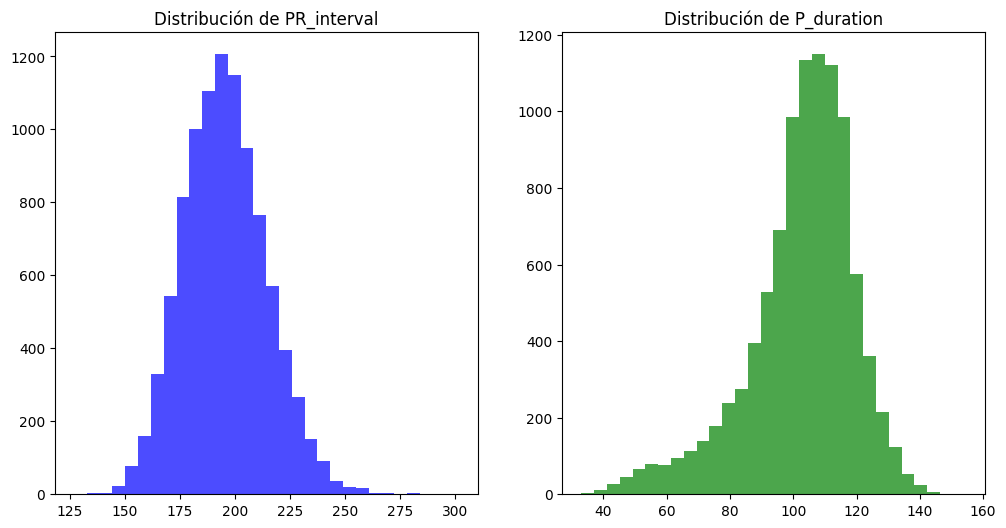

In [120]:
# Distribucion de PR_interval y P_duration
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(features_df['PR_interval'], bins=30, color='blue', alpha=0.7)
plt.title('Distribución de PR_interval')
plt.subplot(1, 2, 2)
plt.hist(features_df['P_duration'], bins=30, color='green', alpha=0.7)
plt.title('Distribución de P_duration')
plt.show()

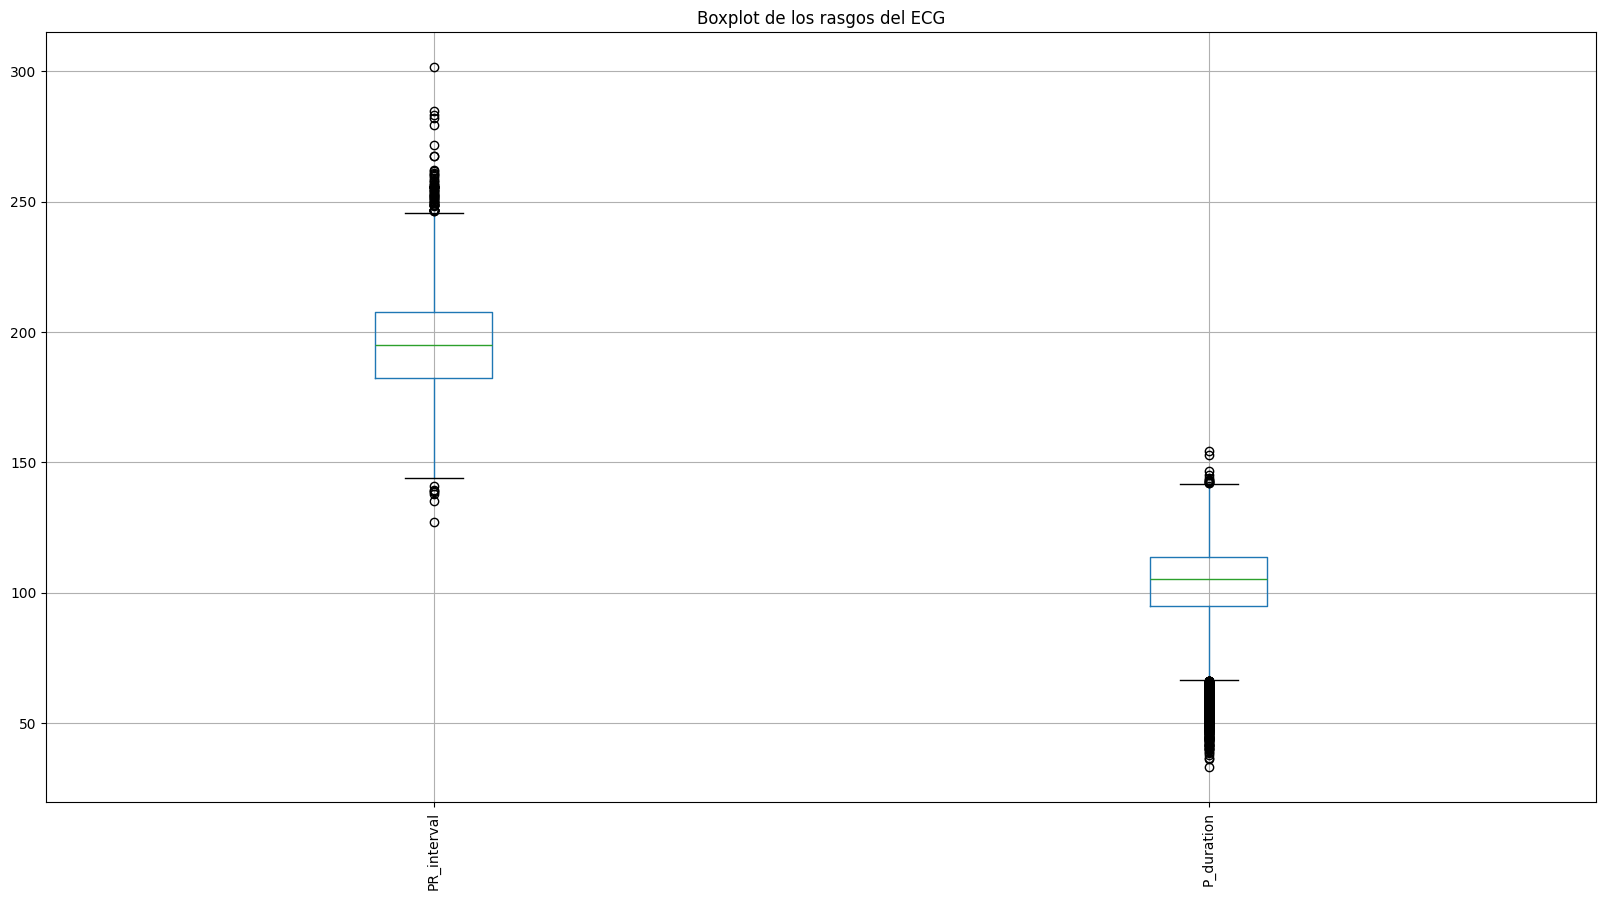

In [121]:
# Analisis de Outliers (Valores en tiempo)
features_df.loc[:, ['PR_interval','P_duration']].boxplot(figsize=(20, 10))
plt.xticks(rotation=90)
plt.title('Boxplot de los rasgos del ECG')
plt.show()


In [122]:
# Aplicar RobustScaler a los rasgos de tiempo
from sklearn.preprocessing import RobustScaler

features_df_no_outliers_scaled = features_df.copy()

scaler = RobustScaler(
    quantile_range=(5.0, 95.0)
)
features_df_no_outliers_scaled.loc[:, ['PR_interval', 'P_duration']] = scaler.fit_transform(features_df_no_outliers_scaled.loc[:, ['PR_interval', 'P_duration']])

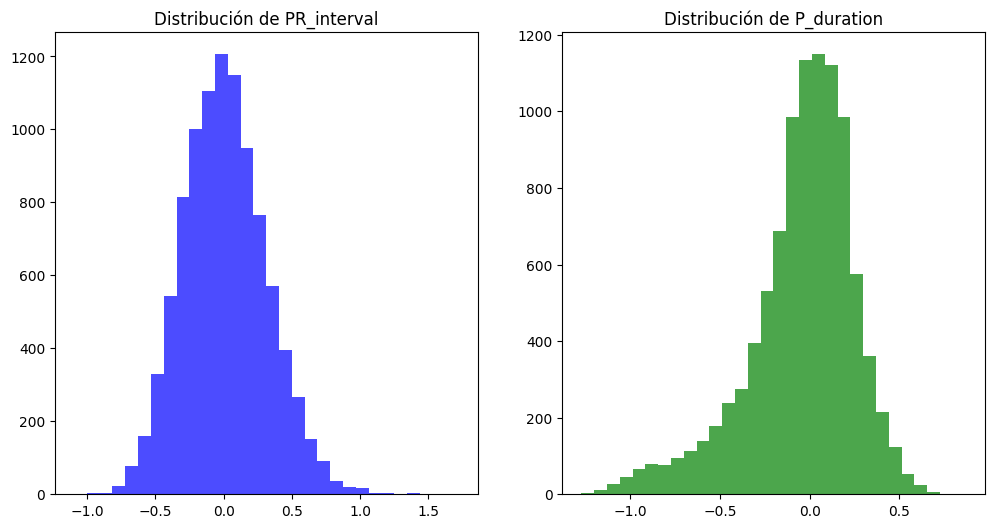

In [123]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(features_df_no_outliers_scaled['PR_interval'], bins=30, color='blue', alpha=0.7)
plt.title('Distribución de PR_interval')
plt.subplot(1, 2, 2)
plt.hist(features_df_no_outliers_scaled['P_duration'], bins=30, color='green', alpha=0.7)
plt.title('Distribución de P_duration')
plt.show()

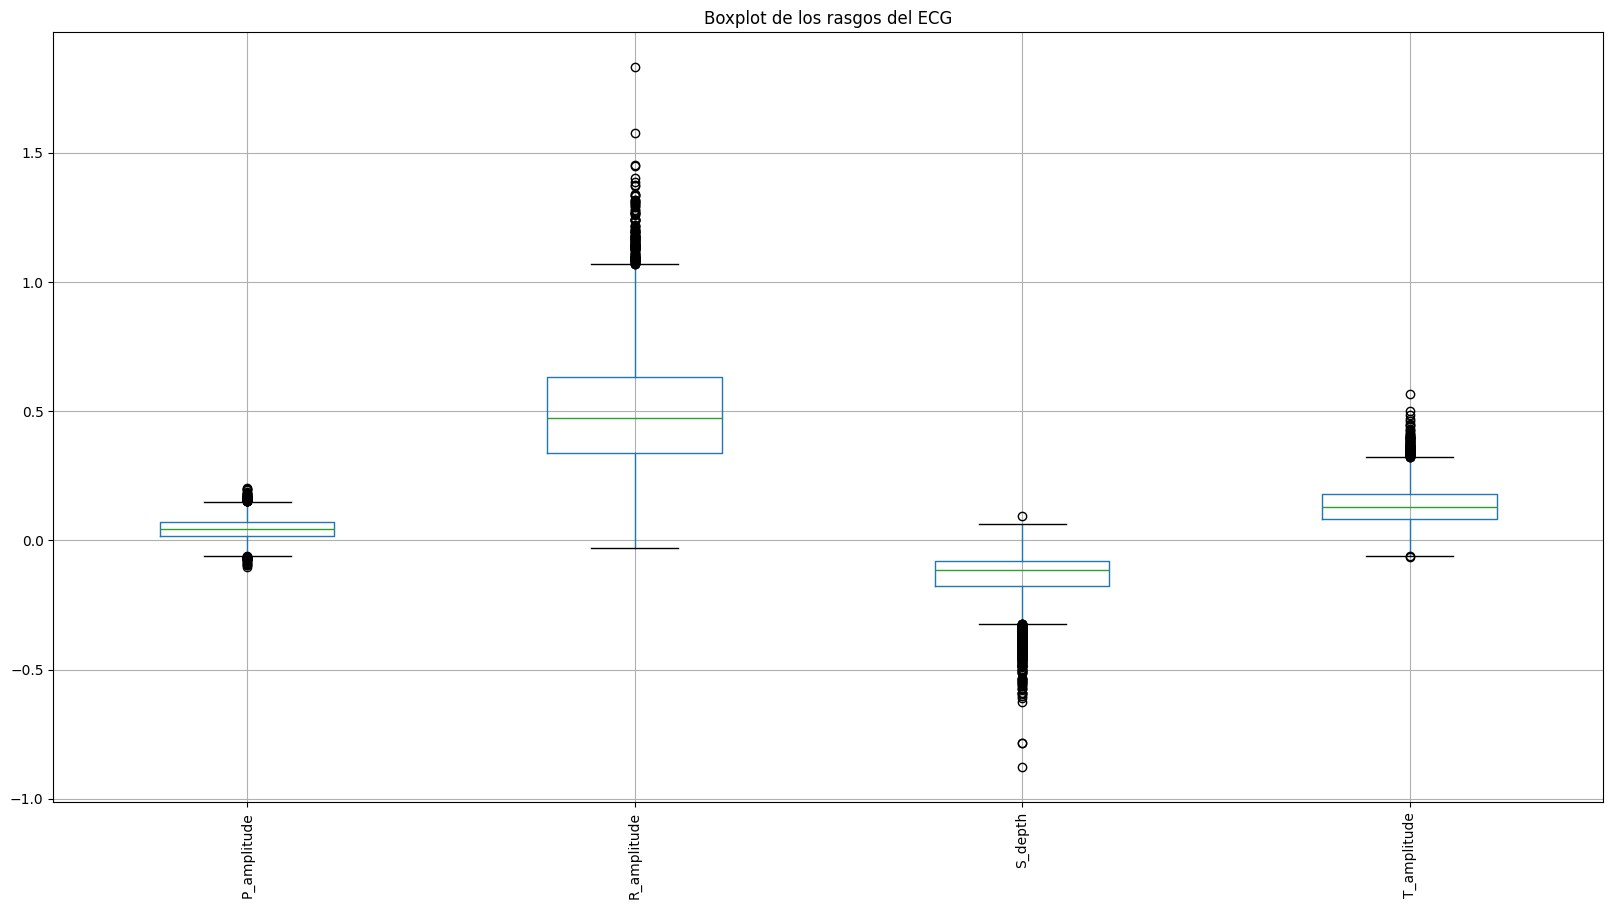

In [124]:
# Analisis de Outliers (Valores de amplitud)
features_df.iloc[:, 3:].boxplot(figsize=(20, 10))
plt.xticks(rotation=90)
plt.title('Boxplot de los rasgos del ECG')
plt.show()

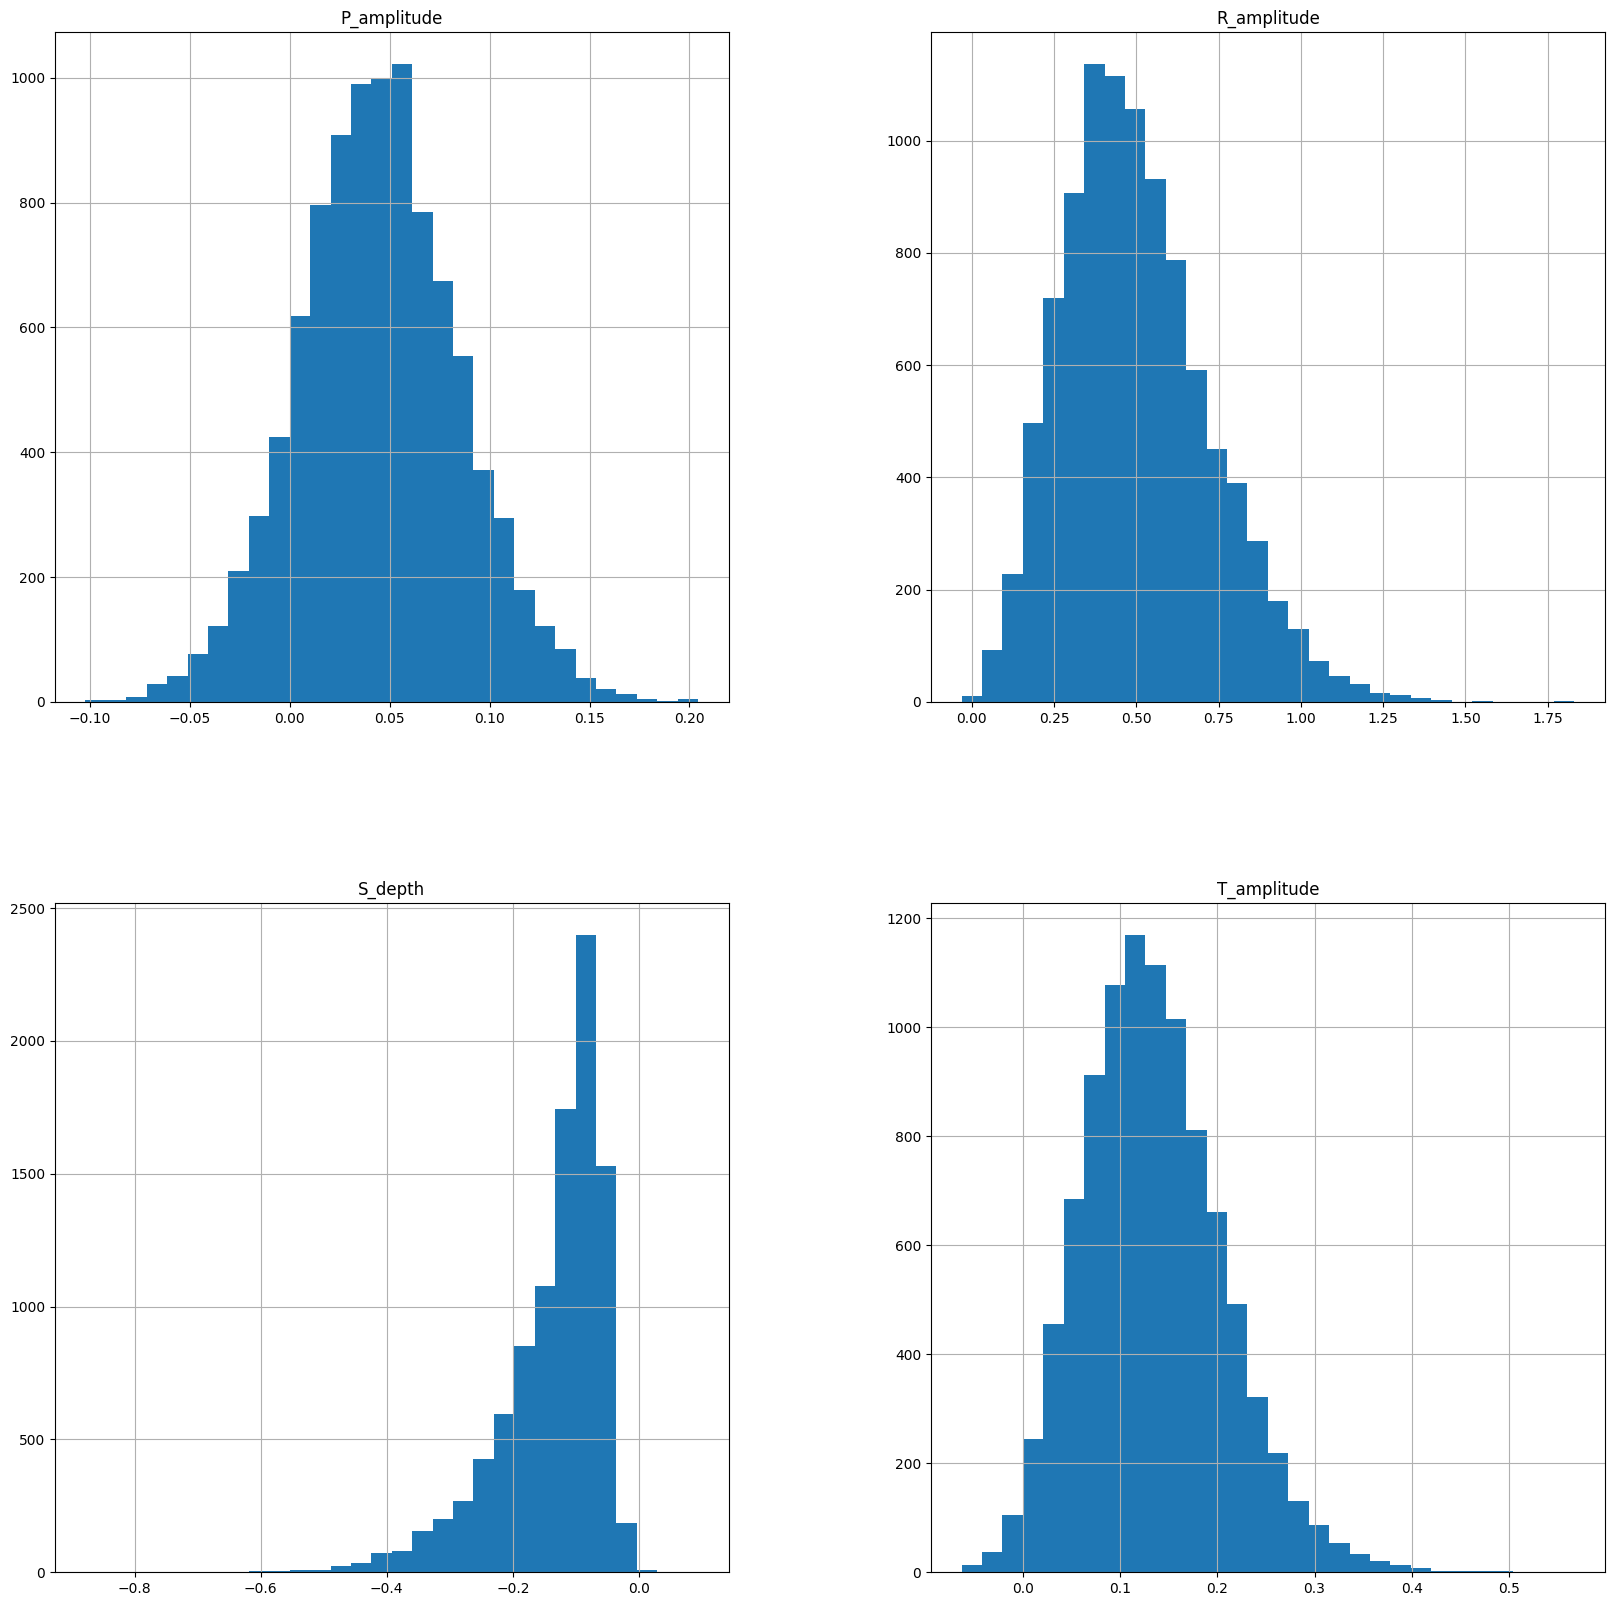

In [125]:
# An'alisis de distribuci'on de los rasgos de amplitud
features_df.iloc[:, 3:].hist(figsize=(20, 20), bins=30)
plt.show()

In [126]:
from sklearn.preprocessing import RobustScaler

features_df_scaled = features_df_no_outliers_scaled.copy()
scaler = RobustScaler(
    quantile_range=(5.0, 95.0)
)
features_df_scaled.iloc[:, 2:] = scaler.fit_transform(features_df_scaled.iloc[:, 2:])

### Analisis general de distribucion de los rasgos del ECG

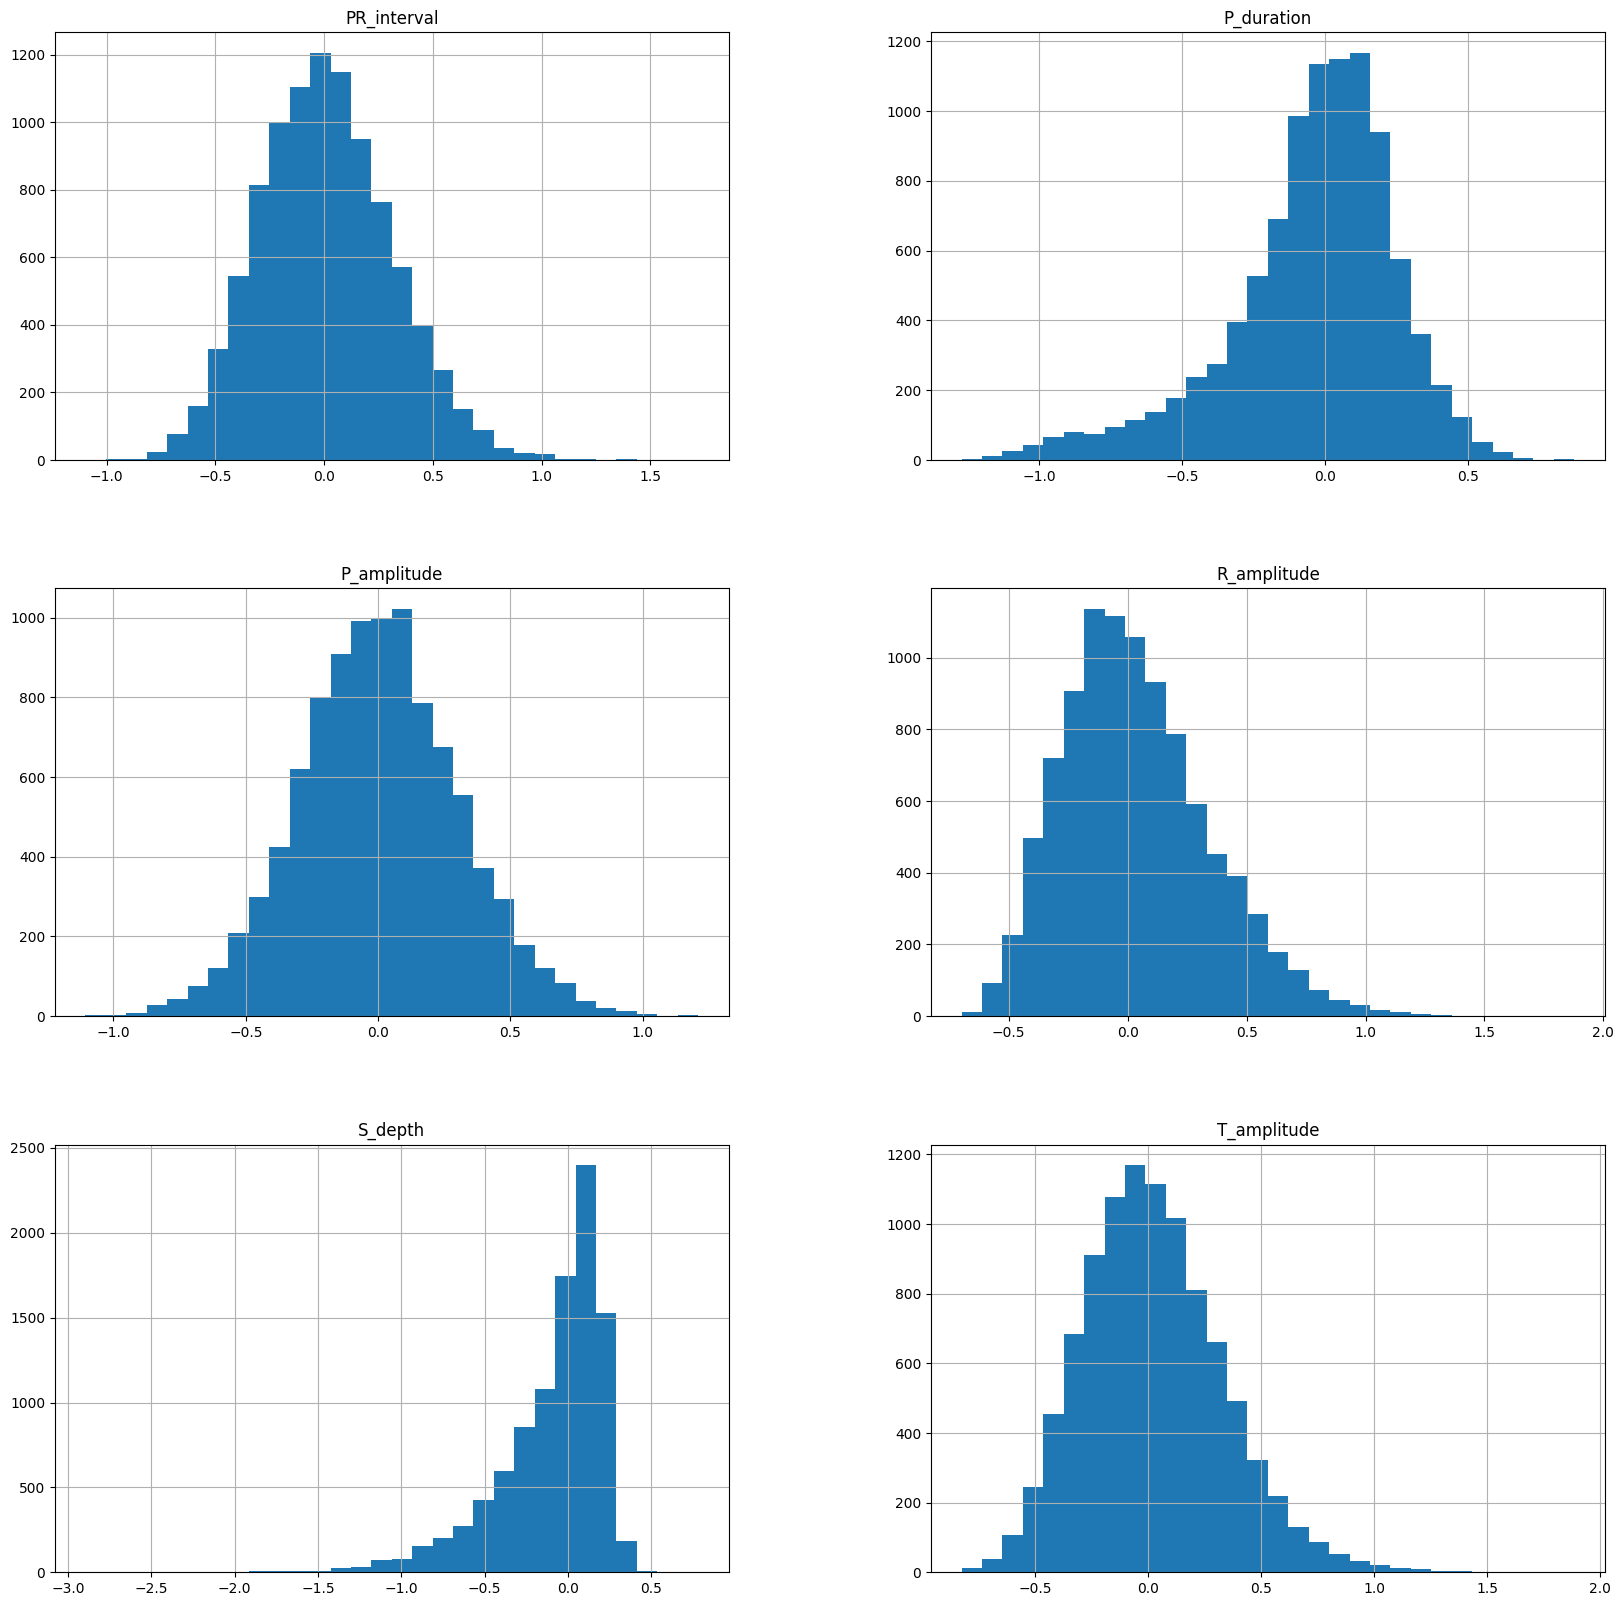

In [127]:
features_df_scaled.iloc[:, 1:].hist(figsize=(20, 20), bins=30)
plt.show()

In [128]:
X_final = features_df_scaled.copy()
X_final.head()

,ECG_ID,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude
0,A00002,0.256824,0.017406,-0.440486,0.662585,0.222963,-0.282507
1,A00003,0.195565,0.027917,0.827458,-0.070707,0.051890,-0.277537
2,A00006,0.212903,0.307385,0.054002,0.055471,0.149587,0.018080
3,A00008,-0.077419,0.078169,0.087648,0.330885,0.079797,0.279721
4,A00009,-0.553763,-0.085222,0.184517,0.026673,-0.081408,0.070555


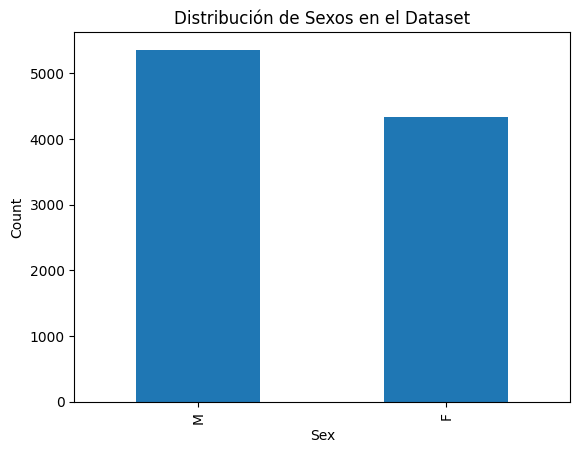

In [129]:
# Data exploring
y_series.value_counts().plot(kind='bar')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribución de Sexos en el Dataset')
plt.show()

In [130]:
# Porcentaje de sexos
sex_M = y_series.value_counts().iloc[0]
sex_F = y_series.value_counts().iloc[1]
print(f"Porcentaje de hombres con respecto al total: {sex_M/len(y_series)*100:.2f}%")
print(f"Porcentaje de mujeres con respecto al total: {sex_F/len(y_series)*100:.2f}%")

Porcentaje de hombres con respecto al total: 55.29%
Porcentaje de mujeres con respecto al total: 44.71%


In [131]:
# Etiquetado de la variable objetivo
y_series = y_series.map({'M': 1, 'F': 0})

In [110]:
# merge X_final con y_series
final_df = pd.concat([X_final, y_series], axis=1)
final_df.set_index("ECG_ID", inplace=True)
final_df.head()


,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude,Sex
ECG_ID,,,,,,,
A00002,0.256824,0.017406,-0.440486,0.662585,0.222963,-0.282507,1
A00003,0.195565,0.027917,0.827458,-0.070707,0.051890,-0.277537,1
A00006,0.212903,0.307385,0.054002,0.055471,0.149587,0.018080,0
A00008,-0.077419,0.078169,0.087648,0.330885,0.079797,0.279721,1
A00009,-0.553763,-0.085222,0.184517,0.026673,-0.081408,0.070555,0


In [132]:
# Save df
final_df.to_csv("../data/datasets/df_to_train.csv")